### Importing libraries

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests 

# Functions to automate the data analysis and vizualization  process.

### API Functions

Function that calls a get api request and returns a nested json file.

In [83]:
def api_get_data(url="https://dummyjson.com/",dataset="",params=None):

    try:
        response = requests.get(
            url + dataset,
            params=params
        )

        response.raise_for_status()

        return response.json()

    except requests.exceptions.RequestException as e:
        print(f"API Error: {e}")

        return None

raw_carts_df=api_get_data(dataset="carts")

Function that normalize the json file usig the .json_normalize() pandas built-in function.

In [84]:
def convert_to_pandas_df(
    raw_df,
    df_name=None,
    record_path=None,
    meta=None
):

    # Gets the first top-level key from the dictionary
    main_key = list(raw_df.keys())[0]

    # The nested list to explode into rows
    if record_path:

        pd_df = pd.json_normalize(
            raw_df[main_key],
            record_path=record_path,
            # Parent fields to keep
            meta=meta,
            # Prefix added to parent columns
            meta_prefix=df_name,
             # Ignore missing metadata fields
            errors="ignore"
        )

    else:
        
        # Simple normalization without nested extraction
        pd_df = pd.json_normalize(
            raw_df[main_key]
        )

    return pd_df

### Data Cleaning Functions

In [85]:
#Counts the duplicate rows and remove them from the dataframe informing the user.

def remove_duplicates(dataframe):
    dupl_rows=dataframe.duplicated().sum()
    dataframe=dataframe.drop_duplicates()
    print(f"{dupl_rows} duplicates have been found and removed from the dataframe.")
    return dataframe

In [86]:
# Loops throughout the column dictionary and corrects the data types.

def cast_columns(dataframe, columns_dict={}, date_format="%Y-%m-%d"):

    for column, dtype in columns_dict.items():

        if dtype == "str":
            dataframe[column] = dataframe[column].astype("string")

        elif dtype == "int":
            dataframe[column] = dataframe[column].astype("Int64")

        elif dtype == "float":
            dataframe[column] = dataframe[column].astype("float")

        elif dtype == "date":
            dataframe[column] = pd.to_datetime(dataframe[column],format=date_format)

    return dataframe

In [87]:
# Creates 2 lists. One for numeric columns and one for the date columns.
# Loops in num list, removes from the dataframe numeric values with <=0 and saves them in a separate dataframe.
# Loops in date list, removes from the dataframe date greater than the current date and saves in a separate dataframe.

def inconsistent_values(dataframe, min_num_value=0):

    inc_values_df = pd.DataFrame()

    num_cols = dataframe.select_dtypes(include=["number"]).columns

    date_cols = dataframe.select_dtypes(include=["datetime64"]).columns

    for col in num_cols:
        num_inc_rows = dataframe[dataframe[col] <= min_num_value]

        inc_values_df = pd.concat([inc_values_df, num_inc_rows])
        dataframe = dataframe[dataframe[col] > min_num_value]

        print(f"The {col} contains {len(num_inc_rows)} incosistent numbers which have been excluded from the analysis.")
        print(f"Adding these values to the incosistent_values_df")

    for col in date_cols:
        date_inc_rows = dataframe[dataframe[col] > pd.Timestamp("today")]

        inc_values_df = pd.concat([inc_values_df, date_inc_rows])
        dataframe = dataframe[dataframe[col] <= pd.Timestamp("today")]

        print(f"The {col} contains {len(date_inc_rows)} incosistent dates which have been excluded from the analysis.")
        print(f"Adding these values to the incosistent_values_df")

    return dataframe, inc_values_df

In [88]:
#Cleans the incosistent values of the column with the use of the replace pd function. Returns the dataframe cleaned.
#Parse parameters the dataframe, the column and the replace_parameteres dictionary to clean the str values.

def replace_string_values(dataframe,column,replace_parameteres):

    # Removes any possible spaces and trims the column's values.
    dataframe[column]=dataframe[column].str.strip()

    # Converts the string to upper letters if it equal or less than 3 digit.Otherwise converts to upper only the first letter.
    dataframe[column]=dataframe[column].apply(lambda x: x.upper() if len(x)<=3 else x.title())

    dataframe[column]=dataframe[column].replace(replace_parameteres)
    return dataframe

### Data Analysis Functions

In [89]:
def find_max_value(dataframe,column):
    max_value=dataframe[column].max()
    return max_value

In [90]:
def find_min_value(dataframe,column):
    min_value=dataframe[column].min()
    return min_value

In [91]:
def find_average_value(dataframe,column):
    mean_value=dataframe[column].mean()
    return mean_value

In [92]:
def find_sum_value(dataframe,column):
    sum_value=dataframe[column].sum()
    return sum_value

In [93]:
#Group by function under the column list in parameteres and the agg pandas function with group_by_parameteres in a dictionary format.

def group_by(dataframe,groupby_columns,group_by_parameters):
    summary_df=dataframe.groupby(groupby_columns).agg(group_by_parameters)
    return summary_df


In [94]:
def create_basic_analysis_table(dataframe,revenue_col,orders_col,category_col, payment_col,country_col,place="country",method="payment"):

    analysis_table=pd.DataFrame(
        {
            "Total_revenue": [dataframe[revenue_col].sum()],
            "Total_orders":[dataframe[orders_col].count()],
            "Average_order_value": [dataframe[revenue_col].mean()],
            "Top Category":[dataframe.groupby(category_col)[revenue_col].sum().idxmax()],
            f"Most Common {method}":[dataframe.groupby(payment_col)[orders_col].count().idxmax()],
            f"Most Profitable {place} in Total Values":[dataframe.groupby(country_col)[revenue_col].sum().idxmax()],
           f"Least Profitable {place} in Total Values":[dataframe.groupby(country_col)[revenue_col].sum().idxmin()]
        }
    )

    return analysis_table


### Data Vizualization Functions

In [95]:
def create_bar_chart(dataframe,x_column,y_column, estimator,chart_title,x_title,y_title,filter=None, palette="viridis"):

    # Sort dataframe in descending order
    sorted_df=dataframe.sort_values(
        by=y_column,
        ascending=False
        )

    # Formating the graph's size 
    plt.figure(figsize=(10,10))

    # Create simple bar chart
    barchart= sns.barplot(
                x=x_column ,
                y=y_column, 
                data=sorted_df,
                errorbar=None,
                estimator=estimator,
                hue=filter,
                palette=palette)
    
    # Chart title
    plt.title(chart_title,fontsize=20)

    # Axis titles
    plt.xlabel(x_title,fontsize=15)
    plt.ylabel(y_title,fontsize=15)
    
    # Legend position
    plt.legend(loc="upper right")

    plt.show()

    return barchart

In [96]:
def create_lineplot_graph(dataframe,x_column,y_column,estimator,chart_title,x_title,y_title,filter=None, palette="deep"):

    # Formating the graph's size 
    plt.figure(figsize=(10,10))
    
    # Create a line plot 

    lineplot=sns.lineplot(
        data=dataframe,
        x=x_column,
        y=y_column,
        estimator=estimator,
        errorbar=None,
        hue=filter,
        palette=palette
    )

    #Chart title
    plt.title(chart_title, fontsize=20)

    # Axis titles
    plt.xlabel(x_title,fontsize=15)
    plt.ylabel(y_title,fontsize=15)

    #Positioning the legend
    plt.legend(loc="upper right")

    plt.show()

    return lineplot

    

In [ ]:
def create_scatterplot(dataframe,x_column,y_column,chart_title,x_title,y_title,filter=None, palette="muted"):

    # Formating the graph's size 
    plt.figure(figsize=(10,10))

    #Create a scatterplot graph

    scatterplot=sns.scatterplot(
        data=dataframe,
        x=x_column,
        y=y_column,
        hue=filter,
        palette=palette,
        alpha=0.7
    )
    
    # Adding graph title
    plt.title(chart_title,fontsize=20)

    # Adding axis titles
    plt.xlabel(x_title,fontsize=15)
    plt.ylabel(y_title,fontsize=15)

    plt.show()

    return scatterplot

In [189]:
def create_histogram(dataframe,column,filter=None,palette="viridis"):

    # Formating the graph's size 
    plt.figure(figsize=(10,10))

    # Create histogram
    histogram=sns.histplot(
        dataframe[column], 
        kde=True,
        hue=filter,
        color=sns.color_palette(palette)[3]
    )

    # Adding graph title
    plt.title(f"{column.title()} Distribution")

    # Adding axis titles
    plt.xlabel(column.title(),fontsize=15)
    plt.ylabel("Count",fontsize=15)

    plt.show()

    return histogram

In [193]:
def create_heatmap(dataframe,numeric_cols=[],palette="coolwarm"):

    # Formating the graph's size 
    plt.figure(figsize=(10,10))

    # Creating coorelation matrix
    matrix=dataframe[numeric_cols].corr()

    # Creating heatmap
    heatmap=sns.heatmap(
        matrix,
        annot=True,
        cmap=palette
    )

    # Adding title
    plt.title("Coorelation Heatmap")

    plt.show()

    return matrix

# Mock_data Analysis and Visualization

Reading the raw dataframe and displaying the basic info.

In [98]:
raw_data= pd.read_csv("mock_ecommerce_dataset_2000_rows.csv")
raw_data.info()
raw_data.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        2000 non-null   int64  
 1   customer_id     2000 non-null   str    
 2   product_name    2000 non-null   str    
 3   category        2000 non-null   str    
 4   quantity        1985 non-null   float64
 5   unit_price      1978 non-null   float64
 6   order_date      2000 non-null   str    
 7   payment_method  1977 non-null   str    
 8   country         2000 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 140.8 KB


,order_id,customer_id,product_name,category,quantity,unit_price,order_date,payment_method,country
0,1,C164,Yoga Mat,Sports,1.0,33.12,2025-03-26,Debit Card,Germany
1,2,C190,Laptop Sleeve,Electronics,1.0,27.23,2025-06-15,Bank Transfer,Greece
2,3,C130,Protein Powder,Sports,1.0,37.19,2025-06-07,Debit Card,Netherlands
3,4,C057,Fitness Tracker,Electronics,5.0,82.49,2025-03-27,Credit Card,Germany
4,5,C040,Bluetooth Speaker,Electronics,3.0,57.76,2025-02-10,Credit Card,Spain
5,6,C155,Phone Case,Electronics,1.0,17.62,2025-05-12,Credit Card,Spain
6,7,C161,Protein Powder,Sports,3.0,32.55,2025-06-11,Debit Card,Netherlands
7,8,C198,Resistance Bands,Sports,1.0,21.22,2025-03-15,Credit Card,Spain
8,9,C094,Water Bottle,Sports,3.0,14.14,2025-04-15,Debit Card,Netherlands
9,10,C166,USB-C Cable,Electronics,5.0,15.33,2025-06-26,Debit Card,Italy


Parameters to use for the analysis

In [99]:
# Dictionary with the dataframe's columns in key and the correct datatype as value.

column_dict={
    "order_id":"int",
    "customer_id":"str",
    "product_name":"str",
    "category":"str",
    "quantity":"int",
    "unit_price":"float",
    "order_date":"date",
    "payment_method":"str",
    "country":"str"
}

date_format="%Y-%m-%d"

### Data Cleansing

Removing duplicates and parcing the correct datatype. 

In [100]:
clean_df=remove_duplicates(raw_data)
clean_df=cast_columns(clean_df,column_dict,date_format)
clean_df.info()

0 duplicates have been found and removed from the dataframe.
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        2000 non-null   Int64         
 1   customer_id     2000 non-null   string        
 2   product_name    2000 non-null   string        
 3   category        2000 non-null   string        
 4   quantity        1985 non-null   Int64         
 5   unit_price      1978 non-null   float64       
 6   order_date      2000 non-null   datetime64[us]
 7   payment_method  1977 non-null   string        
 8   country         2000 non-null   string        
dtypes: Int64(2), datetime64[us](1), float64(1), string(5)
memory usage: 144.7 KB


Exclude null values from the analysis and saving them separetely to analyze further.

In [101]:
null_values_df=clean_df[clean_df.isnull().any(axis=1)] 
print (f"{len(null_values_df)} rows contain at least 1 null value. They have been excluded from the analysis and saved separetely for audit investigation.")
clean_df=clean_df.dropna()
clean_df.info()

60 rows contain at least 1 null value. They have been excluded from the analysis and saved separetely for audit investigation.
<class 'pandas.DataFrame'>
Index: 1940 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1940 non-null   Int64         
 1   customer_id     1940 non-null   string        
 2   product_name    1940 non-null   string        
 3   category        1940 non-null   string        
 4   quantity        1940 non-null   Int64         
 5   unit_price      1940 non-null   float64       
 6   order_date      1940 non-null   datetime64[us]
 7   payment_method  1940 non-null   string        
 8   country         1940 non-null   string        
dtypes: Int64(2), datetime64[us](1), float64(1), string(5)
memory usage: 155.4 KB


In [102]:
clean_df["country"].unique()

<StringArray>
[    'Germany',      'Greece', 'Netherlands',       'Spain',       'Italy',
      'France',          'IT',          'GR',          'SP',          'GE',
          'FR',          'NE']
Length: 12, dtype: string

In [103]:
clean_df=replace_string_values(clean_df,"country",replace_parameteres={
    "FR":"France",
    "GE":"Germany",
    "GR":"Greece",
    "NE":"Netherlands",
    "IT":"Italy",
    "SP":"Spain"
})
clean_df["customer_id"]=clean_df["customer_id"].str.upper()
clean_df["country"].unique()

<StringArray>
['Germany', 'Greece', 'Netherlands', 'Spain', 'Italy', 'France']
Length: 6, dtype: str

Removing the incosistent numeric and date values.

In [104]:
final_df, inc_values_df=inconsistent_values(clean_df)
final_df.info()

The order_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The quantity contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The unit_price contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The order_date contains 0 incosistent dates which have been excluded from the analysis.
Adding these values to the incosistent_values_df
<class 'pandas.DataFrame'>
Index: 1940 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1940 non-null   Int64         
 1   customer_id     1940 non-null   string        
 2   product_name    1940 non-null   string        
 3   category        1940 non-null   string        
 4   quantity        1940 non-null   Int64      

In [105]:
inc_values_df.info()

<class 'pandas.DataFrame'>
Index: 0 entries
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        0 non-null      Int64         
 1   customer_id     0 non-null      string        
 2   product_name    0 non-null      string        
 3   category        0 non-null      string        
 4   quantity        0 non-null      Int64         
 5   unit_price      0 non-null      float64       
 6   order_date      0 non-null      datetime64[us]
 7   payment_method  0 non-null      string        
 8   country         0 non-null      str           
dtypes: Int64(2), datetime64[us](1), float64(1), str(1), string(4)
memory usage: 0.0 bytes


### Data Analysis

Adding revenue column calculating the quanity*unit_price.

Reordering the column order using the iloc function

In [106]:
final_df["revenue"]=final_df["quantity"]*final_df["unit_price"]

# Reordering the columns using the .iloc pd function
final_df=final_df.iloc[:,[0,1,2,3,4,5,9,6,7,8,]]
final_df

,order_id,customer_id,product_name,category,quantity,unit_price,revenue,order_date,payment_method,country
0,1,C164,Yoga Mat,Sports,1,33.12,33.12,2025-03-26,Debit Card,Germany
1,2,C190,Laptop Sleeve,Electronics,1,27.23,27.23,2025-06-15,Bank Transfer,Greece
2,3,C130,Protein Powder,Sports,1,37.19,37.19,2025-06-07,Debit Card,Netherlands
3,4,C057,Fitness Tracker,Electronics,5,82.49,412.45,2025-03-27,Credit Card,Germany
4,5,C040,Bluetooth Speaker,Electronics,3,57.76,173.28,2025-02-10,Credit Card,Spain
...,...,...,...,...,...,...,...,...,...,...
1995,1996,C081,Protein Powder,Sports,5,36.83,184.15,2025-03-07,Debit Card,Italy
1996,1997,C016,Bluetooth Speaker,Electronics,5,63.32,316.6,2025-05-24,PayPal,Germany
1997,1998,C210,Wireless Mouse,Electronics,3,25.36,76.08,2025-03-22,Debit Card,Germany
1998,1999,C165,HDMI Cable,Electronics,1,15.56,15.56,2025-04-19,Bank Transfer,Germany


Extracting the year and the month from the date column and saving them separetely.

In [107]:
final_df["year"]=final_df["order_date"].dt.year
final_df["month"]=final_df["order_date"].dt.month
final_df

,order_id,customer_id,product_name,category,quantity,unit_price,revenue,order_date,payment_method,country,year,month
0,1,C164,Yoga Mat,Sports,1,33.12,33.12,2025-03-26,Debit Card,Germany,2025,3
1,2,C190,Laptop Sleeve,Electronics,1,27.23,27.23,2025-06-15,Bank Transfer,Greece,2025,6
2,3,C130,Protein Powder,Sports,1,37.19,37.19,2025-06-07,Debit Card,Netherlands,2025,6
3,4,C057,Fitness Tracker,Electronics,5,82.49,412.45,2025-03-27,Credit Card,Germany,2025,3
4,5,C040,Bluetooth Speaker,Electronics,3,57.76,173.28,2025-02-10,Credit Card,Spain,2025,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,C081,Protein Powder,Sports,5,36.83,184.15,2025-03-07,Debit Card,Italy,2025,3
1996,1997,C016,Bluetooth Speaker,Electronics,5,63.32,316.6,2025-05-24,PayPal,Germany,2025,5
1997,1998,C210,Wireless Mouse,Electronics,3,25.36,76.08,2025-03-22,Debit Card,Germany,2025,3
1998,1999,C165,HDMI Cable,Electronics,1,15.56,15.56,2025-04-19,Bank Transfer,Germany,2025,4


Basic Analysis using the describe function.

In [108]:
final_df.describe(include="all")

,order_id,customer_id,product_name,category,quantity,unit_price,revenue,order_date,payment_method,country,year,month
count,1940.0,1940,1940,1940,1940.0,1940.000000,1940.0,1940,1940,1940,1940.0,1940.000000
unique,<NA>,250,20,4,<NA>,NaN,<NA>,NaN,4,6,NaN,NaN
top,<NA>,C068,Tennis Racket,Electronics,<NA>,NaN,<NA>,NaN,Bank Transfer,Netherlands,NaN,NaN
freq,<NA>,18,117,764,<NA>,NaN,<NA>,NaN,502,394,NaN,NaN
mean,1001.922165,NaN,NaN,NaN,2.988144,39.931722,119.456304,2025-04-13 20:54:25.979381,NaN,NaN,2025.0,3.937629
min,1.0,NaN,NaN,NaN,1.0,5.500000,5.66,2025-01-15 00:00:00,NaN,NaN,2025.0,1.000000
25%,501.75,NaN,NaN,NaN,2.0,16.600000,40.575,2025-02-27 18:00:00,NaN,NaN,2025.0,2.000000
50%,1001.5,NaN,NaN,NaN,3.0,30.660000,78.7,2025-04-12 12:00:00,NaN,NaN,2025.0,4.000000
75%,1502.25,NaN,NaN,NaN,4.0,58.717500,163.2075,2025-05-29 00:00:00,NaN,NaN,2025.0,5.000000
max,2000.0,NaN,NaN,NaN,5.0,124.980000,623.45,2025-07-14 00:00:00,NaN,NaN,2025.0,7.000000


In [109]:
max_revenue=find_max_value(final_df,"revenue")
min_revenue=find_min_value(final_df,"revenue")
sum_revenue=find_sum_value(final_df,"revenue")

In [110]:
country_df=group_by(final_df,["country","category"],{
                                        "revenue":"sum",
                                        "order_id":"count",
                                        "quantity":"sum",
                                        "unit_price":"mean"
})
country_df=country_df.rename(columns={
    "unit_price":"avg_unit_price"
})
country_df.sort_values("revenue", ascending=False)

,,revenue,order_id,quantity,avg_unit_price
country,category,,,,
Netherlands,Electronics,20180.46,164,485,43.321951
Spain,Electronics,19755.66,138,417,44.960725
Greece,Electronics,18370.37,129,378,49.852558
France,Electronics,17963.86,108,339,51.558796
Italy,Electronics,17370.73,119,361,47.718151
Netherlands,Sports,16780.62,126,374,44.226111
Spain,Sports,15391.53,114,334,46.402544
Germany,Electronics,14573.73,106,322,44.315943
Italy,Sports,12510.36,93,286,42.451290


In [111]:
basic_analysis_table=create_basic_analysis_table(final_df,"revenue","order_id","category","payment_method","country")
basic_analysis_table=basic_analysis_table.T
basic_analysis_table

,0
Total_revenue,231745.23
Total_orders,1940
Average_order_value,119.456304
Top Category,Electronics
Most Common payment,Bank Transfer
Most Profitable country in Total Values,Netherlands
Least Profitable country in Total Values,Germany


### Data Visualization

Barchart that displays the renenue for each country and category.

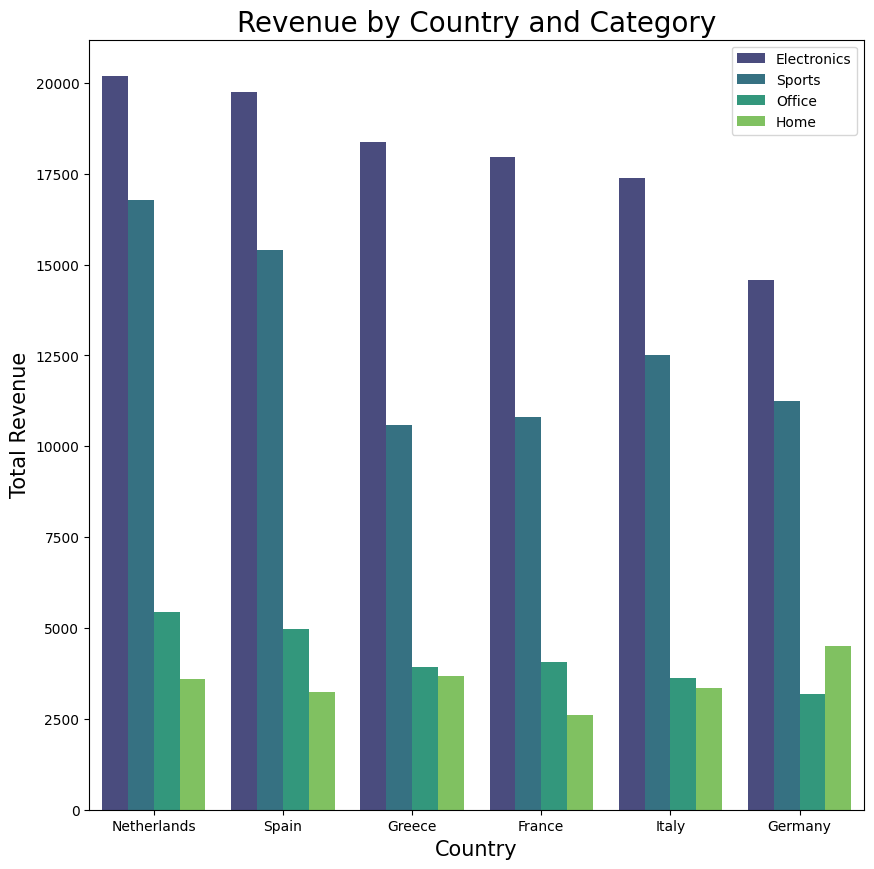

In [112]:
barchart=create_bar_chart(country_df,"country","revenue",sum,"Revenue by Country and Category","Country","Total Revenue","category")

Creating  a dataframe which sums the revenue and count the order for each month.

In [113]:
monthly_df=group_by(final_df,["month","category"],{
    "revenue":"sum",
    "order_id":"count"
})
monthly_df

revenue  order_id
month category                       
1     Electronics  10272.23        69
      Home          2388.68        32
      Office         2110.0        29
      Sports        6711.11        56
2     Electronics  18382.33       118
      Home          2894.94        46
      Office         3948.2        50
      Sports       13709.76        96
3     Electronics  21872.47       150
      Home          3307.98        45
      Office        3978.54        48
      Sports       13302.98        99
4     Electronics  18220.58       128
      Home          3750.27        52
      Office        2995.34        38
      Sports       14688.21       106
5     Electronics  15773.73       110
      Home          3092.39        52
      Office        5777.94        59
      Sports       13024.34        90
6     Electronics  16890.46       123
      Home          4183.01        44
      Office        4658.05        51
      Sports       10875.74        95
7     Electronics   6803.01        66
      Home          1374.15        20
      Office        1741.68        25
      Sports        5017.11        43

Visualizing the above generated dataframe.

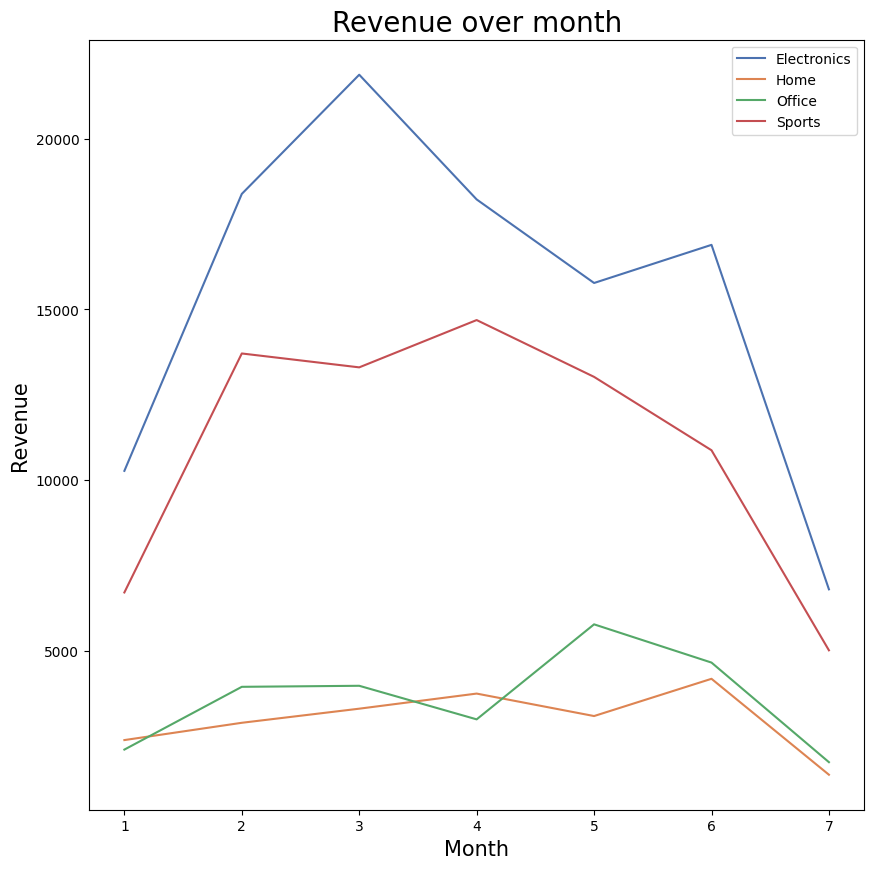

<Axes: title={'center': 'Revenue over month'}, xlabel='Month', ylabel='Revenue'>

In [114]:
lineplot=create_lineplot_graph(monthly_df,"month","revenue",sum,"Revenue over month","Month", "Revenue","category")
lineplot

Create a dataframe for the payment_method

In [115]:
payment_df=group_by(final_df,["payment_method","category"],
                    {
                        "order_id":"count",
                        "revenue":"sum"
                    })
payment_df

order_id   revenue
payment_method category                       
Bank Transfer  Electronics       174  23979.52
               Home               89   6851.06
               Office             84    7825.9
               Sports            155  18975.57
Credit Card    Electronics       193  29371.41
               Home               66   4646.44
               Office             77   5384.63
               Sports            140  19219.82
Debit Card     Electronics       199  26938.92
               Home               73   4298.37
               Office             66   5712.75
               Sports            142   19145.6
PayPal         Electronics       198  27924.96
               Home               63   5195.55
               Office             73   6286.47
               Sports            148  19988.26

Displaying the count of order per payment method and category

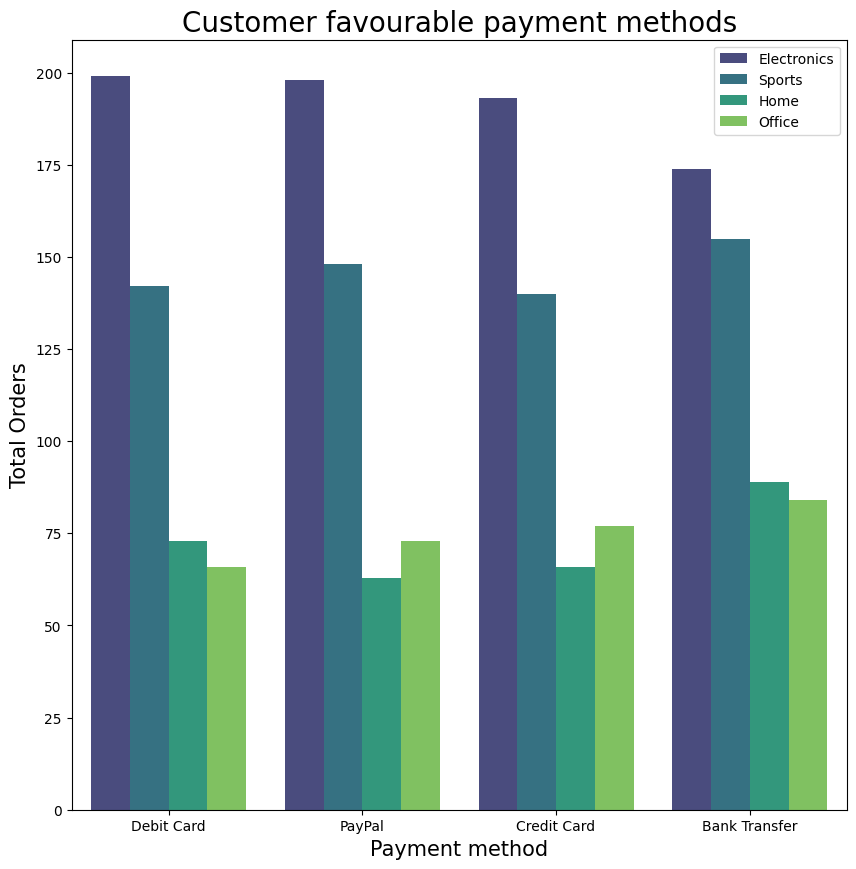

In [116]:
payment_chart=create_bar_chart(payment_df,"payment_method","order_id",sum,"Customer favourable payment methods","Payment method","Total Orders","category")

Examinating possible correlation between unit_price and orders.

In [117]:
product_df=group_by(final_df,["product_name"],
                    {
                        "quantity":"sum",
                        "order_id":"count",
                        "unit_price":"mean"
                    }
                    )
product_df

,quantity,order_id,unit_price
product_name,,,
Bluetooth Speaker,280,89,60.816854
Coffee Mug,316,106,10.712264
Desk Lamp,314,110,45.829545
Desk Organizer,276,96,19.502708
Fitness Tracker,274,94,81.045213
HDMI Cable,249,88,16.043750
Laptop Sleeve,353,116,31.137241
Mechanical Keyboard,310,101,120.923366
Monitor Stand,301,104,56.197115


C:\Users\Dell\AppData\Local\Temp\ipykernel_6960\2217459547.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatterplot=sns.scatterplot(


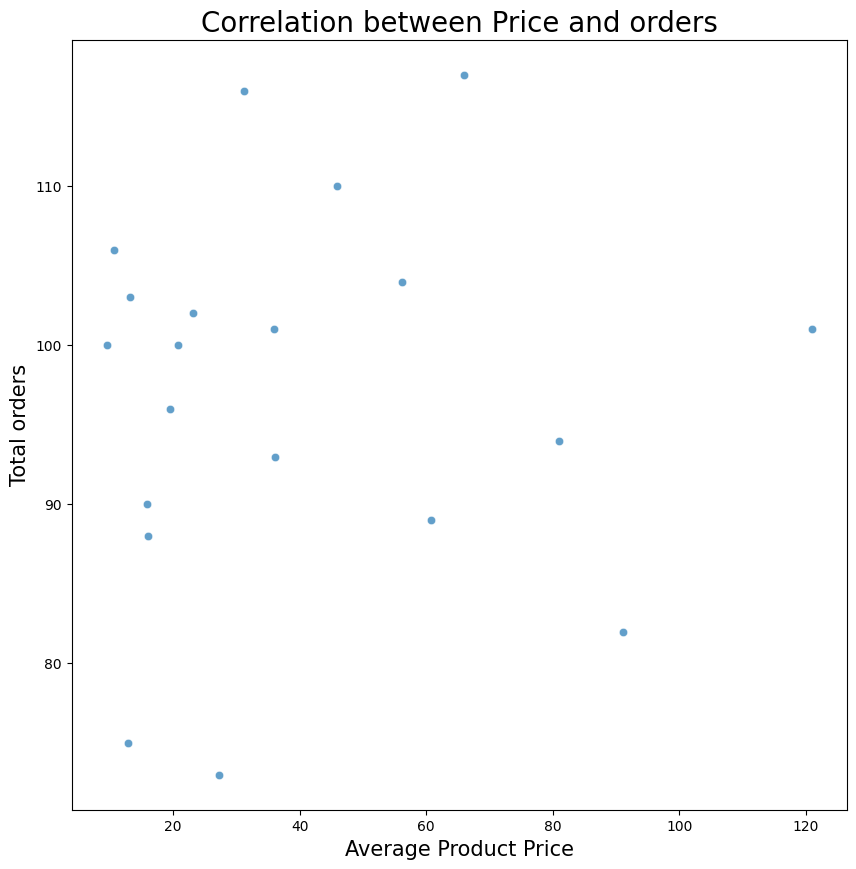

In [118]:
price_quantity_scatterplot=create_scatterplot(product_df,"unit_price","order_id","Correlation between Price and orders","Average Product Price","Total orders")

# Dummy_json_data Analysis and Visualization

### Carts Dataframe Cleaning

In [119]:
raw_carts_df=api_get_data(dataset="carts")

raw_carts_df

{'carts': [{'id': 1,
   'products': [{'id': 162,
     'title': 'Blue Frock',
     'price': 29.99,
     'quantity': 4,
     'total': 119.96,
     'discountPercentage': 12.13,
     'discountedTotal': 105.41,
     'thumbnail': 'https://cdn.dummyjson.com/product-images/tops/blue-frock/thumbnail.webp'},
    {'id': 113,
     'title': 'Generic Motorcycle',
     'price': 3999.99,
     'quantity': 3,
     'total': 11999.97,
     'discountPercentage': 12.1,
     'discountedTotal': 10547.97,
     'thumbnail': 'https://cdn.dummyjson.com/product-images/motorcycle/generic-motorcycle/thumbnail.webp'},
    {'id': 122,
     'title': 'iPhone 6',
     'price': 299.99,
     'quantity': 3,
     'total': 899.97,
     'discountPercentage': 6.69,
     'discountedTotal': 839.76,
     'thumbnail': 'https://cdn.dummyjson.com/product-images/smartphones/iphone-6/thumbnail.webp'},
    {'id': 138,
     'title': 'Baseball Ball',
     'price': 8.99,
     'quantity': 2,
     'total': 17.98,
     'discountPercentage': 1

In [120]:
carts_df = convert_to_pandas_df(raw_carts_df)

In [121]:
carts_df.rename(columns={
    "id": "cart_id",
    "userId": "user_id"
}, inplace=True)
carts_df

,cart_id,products,total,discountedTotal,user_id,totalProducts,totalQuantity
0,1,"[{'id': 162, 'title': 'Blue Frock', 'price': 2...",13037.88,11510.81,1,4,12
1,2,"[{'id': 86, 'title': 'Man Short Sleeve Shirt',...",139.93,125.70,2,2,7
2,3,"[{'id': 24, 'title': 'Fish Steak', 'price': 14...",1794.85,1625.77,3,6,15
3,4,"[{'id': 92, 'title': 'Sports Sneakers Off Whit...",689.93,636.81,4,2,7
4,5,"[{'id': 161, 'title': 'Samsung Galaxy Tab Whit...",1467.88,1205.80,5,3,12
5,6,"[{'id': 192, 'title': 'Rolex Datejust Women', ...",55453.86,46641.06,6,4,14
6,7,"[{'id': 56, 'title': 'Electric Stove', 'price'...",1229.86,1103.65,7,6,14
7,8,"[{'id': 18, 'title': 'Cat Food', 'price': 8.99...",6337.83,5771.32,8,6,17
8,9,"[{'id': 1, 'title': 'Essence Mascara Lash Prin...",29709.90,27993.46,9,4,10
9,10,"[{'id': 41, 'title': 'Tissue Paper Box', 'pric...",152.44,131.34,10,2,6


In [122]:
cart_items_df = convert_to_pandas_df(
    raw_carts_df,
    record_path="products",
    meta=["id", "userId"],
    df_name="cart_"
)

In [123]:
cart_items_df.rename(
    columns={
        "id": "product_id",
        "cart_userId": "user_id"
    },
    inplace=True
)
cart_items_df

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id
0,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1
1,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1
2,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1
3,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1
4,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2
...,...,...,...,...,...,...,...,...,...,...
109,135,Vivo V9,299.99,2,599.98,17.67,493.96,https://cdn.dummyjson.com/product-images/smart...,30,30
110,126,Oppo F19 Pro Plus,399.99,1,399.99,18.64,325.43,https://cdn.dummyjson.com/product-images/smart...,30,30
111,77,Yellow Peeler,5.99,1,5.99,12.48,5.24,https://cdn.dummyjson.com/product-images/kitch...,30,30
112,3,Powder Canister,14.99,5,74.95,9.84,67.57,https://cdn.dummyjson.com/product-images/beaut...,30,30


In [124]:
cart_items_df[cart_items_df.duplicated()]

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id
25,56,Electric Stove,49.99,1,49.99,14.04,42.97,https://cdn.dummyjson.com/product-images/kitch...,7,7


In [125]:
cart_items_df=remove_duplicates(cart_items_df)

1 duplicates have been found and removed from the dataframe.


In [126]:
cart_items_df=cast_columns(cart_items_df,
                       columns_dict={
                           "cart_id":"int",
                           "user_id":"int"
                       }
                       )

In [127]:
cart_items_df

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id
0,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1
1,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1
2,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1
3,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1
4,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2
...,...,...,...,...,...,...,...,...,...,...
109,135,Vivo V9,299.99,2,599.98,17.67,493.96,https://cdn.dummyjson.com/product-images/smart...,30,30
110,126,Oppo F19 Pro Plus,399.99,1,399.99,18.64,325.43,https://cdn.dummyjson.com/product-images/smart...,30,30
111,77,Yellow Peeler,5.99,1,5.99,12.48,5.24,https://cdn.dummyjson.com/product-images/kitch...,30,30
112,3,Powder Canister,14.99,5,74.95,9.84,67.57,https://cdn.dummyjson.com/product-images/beaut...,30,30


In [128]:
cart_items_df,cart_inc_df=inconsistent_values(cart_items_df)

The product_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The price contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The quantity contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The total contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The discountPercentage contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The discountedTotal contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The cart_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The user_id contains 0 incosi

### Products Dataframe Cleansing

In [129]:
raw_pr_df=api_get_data(dataset="products")
raw_pr_df

{'products': [{'id': 1,
   'title': 'Essence Mascara Lash Princess',
   'description': 'The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.',
   'category': 'beauty',
   'price': 9.99,
   'discountPercentage': 10.48,
   'rating': 2.56,
   'stock': 99,
   'tags': ['beauty', 'mascara'],
   'brand': 'Essence',
   'sku': 'BEA-ESS-ESS-001',
   'weight': 4,
   'dimensions': {'width': 15.14, 'height': 13.08, 'depth': 22.99},
   'warrantyInformation': '1 week warranty',
   'shippingInformation': 'Ships in 3-5 business days',
   'availabilityStatus': 'In Stock',
   'reviews': [{'rating': 3,
     'comment': 'Would not recommend!',
     'date': '2025-04-30T09:41:02.053Z',
     'reviewerName': 'Eleanor Collins',
     'reviewerEmail': 'eleanor.collins@x.dummyjson.com'},
    {'rating': 4,
     'comment': 'Very satisfied!',
     'date': '2025-04-30T09:41:02.053Z',
     'review

In [130]:
products_df=convert_to_pandas_df(raw_pr_df,"products")

In [131]:
pd.set_option("display.max_columns", None)

In [132]:
products_df.rename(
    columns={"id":"product_id"},
    inplace=True
)
products_df=products_df[
    ["product_id","title","category","price","discountPercentage","rating","stock","brand","shippingInformation","availabilityStatus","returnPolicy","minimumOrderQuantity"]
    ]


In [133]:
products_df=remove_duplicates(products_df)

0 duplicates have been found and removed from the dataframe.


In [134]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_id            30 non-null     int64  
 1   title                 30 non-null     str    
 2   category              30 non-null     str    
 3   price                 30 non-null     float64
 4   discountPercentage    30 non-null     float64
 5   rating                30 non-null     float64
 6   stock                 30 non-null     int64  
 7   brand                 15 non-null     str    
 8   shippingInformation   30 non-null     str    
 9   availabilityStatus    30 non-null     str    
 10  returnPolicy          30 non-null     str    
 11  minimumOrderQuantity  30 non-null     int64  
dtypes: float64(3), int64(3), str(6)
memory usage: 2.9 KB


In [135]:
products_df, inc_products_df=inconsistent_values(products_df)

The product_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The price contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The discountPercentage contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The rating contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The stock contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The minimumOrderQuantity contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df


### User Dataframe Cleansing

In [136]:
raw_user=api_get_data(dataset="users")

In [137]:
raw_user

{'users': [{'id': 1,
   'firstName': 'Emily',
   'lastName': 'Johnson',
   'maidenName': 'Smith',
   'age': 29,
   'gender': 'female',
   'email': 'emily.johnson@x.dummyjson.com',
   'phone': '+81 965-431-3024',
   'username': 'emilys',
   'password': 'emilyspass',
   'birthDate': '1996-5-30',
   'image': 'https://dummyjson.com/icon/emilys/128',
   'bloodGroup': 'O-',
   'height': 193.24,
   'weight': 63.16,
   'eyeColor': 'Green',
   'hair': {'color': 'Brown', 'type': 'Curly'},
   'ip': '42.48.100.32',
   'address': {'address': '626 Main Street',
    'city': 'Phoenix',
    'state': 'Mississippi',
    'stateCode': 'MS',
    'postalCode': '29112',
    'coordinates': {'lat': -77.16213, 'lng': -92.084824},
    'country': 'United States'},
   'macAddress': '47:fa:41:18:ec:eb',
   'university': 'University of Wisconsin--Madison',
   'bank': {'cardExpire': '05/28',
    'cardNumber': '3693233511855044',
    'cardType': 'Diners Club International',
    'currency': 'GBP',
    'iban': 'GB74MH2UZ

In [138]:
user_df=convert_to_pandas_df(raw_user,"users")
user_df.rename(
    columns={"id":"user_id"},
    inplace=True
)

In [139]:
user_df=user_df[
    ["user_id",
     "firstName",
     "lastName",
     "age",
     "gender",
     "birthDate",
     "height",
     "weight",
     "eyeColor",
     "hair.color",
     "hair.type",
     "address.city",
     "address.stateCode",
     "bank.cardType",
     "bank.currency"]
]
user_df

,user_id,firstName,lastName,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,1,Emily,Johnson,29,female,1996-5-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
1,2,Michael,Williams,36,male,1989-8-10,186.22,76.32,Red,Green,Straight,Houston,AL,JCB,USD
2,3,Sophia,Brown,43,female,1982-11-6,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR
3,4,James,Davis,46,male,1979-5-4,193.31,62.10,Amber,Blonde,Straight,Seattle,PA,Mastercard,CAD
4,5,Emma,Miller,31,female,1994-6-13,192.80,63.62,Green,White,Straight,Jacksonville,CO,Mastercard,NZD
5,6,Olivia,Wilson,23,female,2002-4-20,182.61,58.00,Hazel,Gray,Curly,Fort Worth,TN,American Express,NZD
6,7,Alexander,Jones,39,male,1986-10-20,153.89,77.42,Blue,White,Straight,Indianapolis,DE,Mastercard,PKR
7,8,Ava,Taylor,28,female,1997-8-25,168.47,57.08,Hazel,Red,Kinky,Fort Worth,RI,Mastercard,EUR
8,9,Ethan,Martinez,34,male,1991-2-12,159.19,68.81,Hazel,Purple,Curly,San Antonio,LA,JCB,GBP
9,10,Isabella,Anderson,32,female,1993-6-10,150.56,50.10,Brown,Blonde,Curly,New York,UT,Diners Club International,USD


In [140]:
user_df=remove_duplicates(user_df)

0 duplicates have been found and removed from the dataframe.


In [141]:
user_df

,user_id,firstName,lastName,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,1,Emily,Johnson,29,female,1996-5-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
1,2,Michael,Williams,36,male,1989-8-10,186.22,76.32,Red,Green,Straight,Houston,AL,JCB,USD
2,3,Sophia,Brown,43,female,1982-11-6,177.72,52.60,Hazel,White,Wavy,Washington,AL,Discover,EUR
3,4,James,Davis,46,male,1979-5-4,193.31,62.10,Amber,Blonde,Straight,Seattle,PA,Mastercard,CAD
4,5,Emma,Miller,31,female,1994-6-13,192.80,63.62,Green,White,Straight,Jacksonville,CO,Mastercard,NZD
5,6,Olivia,Wilson,23,female,2002-4-20,182.61,58.00,Hazel,Gray,Curly,Fort Worth,TN,American Express,NZD
6,7,Alexander,Jones,39,male,1986-10-20,153.89,77.42,Blue,White,Straight,Indianapolis,DE,Mastercard,PKR
7,8,Ava,Taylor,28,female,1997-8-25,168.47,57.08,Hazel,Red,Kinky,Fort Worth,RI,Mastercard,EUR
8,9,Ethan,Martinez,34,male,1991-2-12,159.19,68.81,Hazel,Purple,Curly,San Antonio,LA,JCB,GBP
9,10,Isabella,Anderson,32,female,1993-6-10,150.56,50.10,Brown,Blonde,Curly,New York,UT,Diners Club International,USD


In [142]:
user_df=cast_columns(user_df,columns_dict={"birthDate":"date"},date_format="ISO8601")
user_df,user_inc_df=inconsistent_values(user_df)

The user_id contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The age contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The height contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The weight contains 0 incosistent numbers which have been excluded from the analysis.
Adding these values to the incosistent_values_df
The birthDate contains 0 incosistent dates which have been excluded from the analysis.
Adding these values to the incosistent_values_df


In [143]:
user_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            30 non-null     int64         
 1   firstName          30 non-null     str           
 2   lastName           30 non-null     str           
 3   age                30 non-null     int64         
 4   gender             30 non-null     str           
 5   birthDate          30 non-null     datetime64[us]
 6   height             30 non-null     float64       
 7   weight             30 non-null     float64       
 8   eyeColor           30 non-null     str           
 9   hair.color         30 non-null     str           
 10  hair.type          30 non-null     str           
 11  address.city       30 non-null     str           
 12  address.stateCode  30 non-null     str           
 13  bank.cardType      30 non-null     str           
 14  bank.currency      30 n

### Joining dataframes

In [144]:
cart_products_merged=pd.merge(cart_items_df,products_df[["product_id","title","category","rating","brand","shippingInformation","returnPolicy"]], how="outer")

In [145]:
user_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            30 non-null     int64         
 1   firstName          30 non-null     str           
 2   lastName           30 non-null     str           
 3   age                30 non-null     int64         
 4   gender             30 non-null     str           
 5   birthDate          30 non-null     datetime64[us]
 6   height             30 non-null     float64       
 7   weight             30 non-null     float64       
 8   eyeColor           30 non-null     str           
 9   hair.color         30 non-null     str           
 10  hair.type          30 non-null     str           
 11  address.city       30 non-null     str           
 12  address.stateCode  30 non-null     str           
 13  bank.cardType      30 non-null     str           
 14  bank.currency      30 n

In [146]:
orders_merged=pd.merge(cart_products_merged,user_df[["user_id","age","gender","birthDate","height","weight","eyeColor","hair.color","hair.type","address.city","address.stateCode","bank.cardType","bank.currency"]],how="outer")

In [147]:
orders_merged

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id,category,rating,brand,shippingInformation,returnPolicy,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,113,Generic Motorcycle,3999.99,3.0,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
1,122,iPhone 6,299.99,3.0,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
2,138,Baseball Ball,8.99,2.0,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
3,162,Blue Frock,29.99,4.0,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,MS,Diners Club International,GBP
4,86,Man Short Sleeve Shirt,19.99,5.0,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2,NaN,NaN,NaN,NaN,NaN,36.0,male,1989-08-10,186.22,76.32,Red,Green,Straight,Houston,AL,JCB,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,19,Chicken Meat,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,3.19,NaN,Ships in 1 month,7 days return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,21,Cucumber,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,4.07,NaN,Ships in 1-2 business days,7 days return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,27,Honey Jar,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,3.97,NaN,Ships in 1-2 business days,90 days return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,29,Juice,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,3.94,NaN,Ships in 1 week,No return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dummy Json Data Analysis

Customers or products that did not purchased an order yet.

In [148]:
orders_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           128 non-null    int64         
 1   title                128 non-null    str           
 2   price                113 non-null    float64       
 3   quantity             113 non-null    float64       
 4   total                113 non-null    float64       
 5   discountPercentage   113 non-null    float64       
 6   discountedTotal      113 non-null    float64       
 7   thumbnail            113 non-null    str           
 8   cart_id              113 non-null    Int64         
 9   user_id              113 non-null    Int64         
 10  category             35 non-null     str           
 11  rating               35 non-null     float64       
 12  brand                18 non-null     str           
 13  shippingInformation  35 non-null     str      

In [149]:
inactive_cust_count = (
    (orders_merged["cart_id"].isnull()) &
    (orders_merged["user_id"].notnull())
).sum()

In [150]:
if inactive_cust_count !=0:
    print(f"{inactive_cust_count} users have not purchased an order yet.")
else:
    print("All the signed users have proceed at least to one order.")


All the signed users have proceed at least to one order.


In [151]:
not_purchased_products=(
    (orders_merged["cart_id"].isnull()) &
    (orders_merged["product_id"].notnull())
).sum()

In [152]:
if not_purchased_products!=0:
    print(f"{not_purchased_products} products have not been yet placed in an order at all.")
else:
    print(f"All the products have been purchased at least once.")

15 products have not been yet placed in an order at all.


Replacing the state codes with real full names.

In [153]:
us_states = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming"
}

orders_merged["address.stateCode"] = (
    orders_merged["address.stateCode"]
    .str.strip()
    .str.upper()
    .replace(us_states)
)

In [154]:
orders_merged

,product_id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail,cart_id,user_id,category,rating,brand,shippingInformation,returnPolicy,age,gender,birthDate,height,weight,eyeColor,hair.color,hair.type,address.city,address.stateCode,bank.cardType,bank.currency
0,113,Generic Motorcycle,3999.99,3.0,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
1,122,iPhone 6,299.99,3.0,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
2,138,Baseball Ball,8.99,2.0,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
3,162,Blue Frock,29.99,4.0,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,1,1,NaN,NaN,NaN,NaN,NaN,29.0,female,1996-05-30,193.24,63.16,Green,Brown,Curly,Phoenix,Mississippi,Diners Club International,GBP
4,86,Man Short Sleeve Shirt,19.99,5.0,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...,2,2,NaN,NaN,NaN,NaN,NaN,36.0,male,1989-08-10,186.22,76.32,Red,Green,Straight,Houston,Alabama,JCB,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,19,Chicken Meat,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,3.19,NaN,Ships in 1 month,7 days return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,21,Cucumber,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,4.07,NaN,Ships in 1-2 business days,7 days return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,27,Honey Jar,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,3.97,NaN,Ships in 1-2 business days,90 days return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
126,29,Juice,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,groceries,3.94,NaN,Ships in 1 week,No return policy,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Basic Report

In [155]:
orders_basic_analysis=create_basic_analysis_table(orders_merged[orders_merged["cart_id"].notnull()],"total","cart_id","category","bank.cardType","address.stateCode","State","card")
orders_basic_analysis

,Total_revenue,Total_orders,Average_order_value,Top Category,Most Common card,Most Profitable State in Total Values,Least Profitable State in Total Values
0,725628.96,113,6421.495221,furniture,Mastercard,Montana,North Dakota


In [156]:
group_product=group_by(products_df,["returnPolicy"],{
    "rating":"mean",
    "price":"mean",
    "discountPercentage":"mean",
    "stock":"sum",
}
)
group_product.sort_values("rating")

,rating,price,discountPercentage,stock
returnPolicy,,,,
No return policy,3.628000,216.540000,11.261000,636
7 days return policy,3.773333,334.101111,12.028889,631
30 days return policy,3.903333,2.423333,3.496667,46
90 days return policy,4.176667,19.656667,9.636667,71
60 days return policy,4.254000,267.790000,6.984000,264


In [157]:
group_state=group_by(
    orders_merged[orders_merged['cart_id'].notnull()],
    "address.stateCode",
    {
        "total":"sum",
        "cart_id":"count",
        "quantity":"sum",
        "discountPercentage":"mean",
        "discountedTotal":"sum",
        "age":"mean",
        } 
                     )
group_state.sort_values("discountedTotal",ascending=False,inplace=True)
group_state

,total,cart_id,quantity,discountPercentage,discountedTotal,age
address.stateCode,,,,,,
Montana,186110.85,6,15.0,13.060000,155507.16,33.00
Arkansas,133711.78,6,22.0,9.820000,129230.22,34.00
Nevada,111014.85,4,15.0,10.275000,100496.36,42.00
South Dakota,61831.75,5,15.0,10.742000,57397.84,30.00
Tennessee,55453.86,4,14.0,11.827500,46641.06,23.00
West Virginia,37767.32,6,18.0,9.030000,35410.79,25.00
Louisiana,29709.90,4,10.0,9.795000,27993.46,34.00
Missouri,30299.94,2,6.0,13.440000,26780.04,31.00
New Mexico,22142.88,5,12.0,8.210000,21308.13,29.00


In [158]:
orders_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   product_id           128 non-null    int64         
 1   title                128 non-null    str           
 2   price                113 non-null    float64       
 3   quantity             113 non-null    float64       
 4   total                113 non-null    float64       
 5   discountPercentage   113 non-null    float64       
 6   discountedTotal      113 non-null    float64       
 7   thumbnail            113 non-null    str           
 8   cart_id              113 non-null    Int64         
 9   user_id              113 non-null    Int64         
 10  category             35 non-null     str           
 11  rating               35 non-null     float64       
 12  brand                18 non-null     str           
 13  shippingInformation  35 non-null     str      

In [159]:
group_user=group_by(
    orders_merged[orders_merged["cart_id"].notnull()],
    "user_id",
    {
    "discountedTotal":"sum",
    "cart_id":"count",
    "age":"mean"
    }
)
group_user.sort_values("discountedTotal",ascending=False)

,discountedTotal,cart_id,age
user_id,,,
30,155507.16,6,33.0
18,124978.81,2,32.0
27,100496.36,4,42.0
11,57397.84,5,30.0
6,46641.06,4,23.0
12,35410.79,6,25.0
9,27993.46,4,34.0
24,26780.04,2,31.0
19,21308.13,5,29.0


### Dummy Json data visualization

C:\Users\Dell\AppData\Local\Temp\ipykernel_6960\2104945075.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart= sns.barplot(
C:\Users\Dell\AppData\Local\Temp\ipykernel_6960\2104945075.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


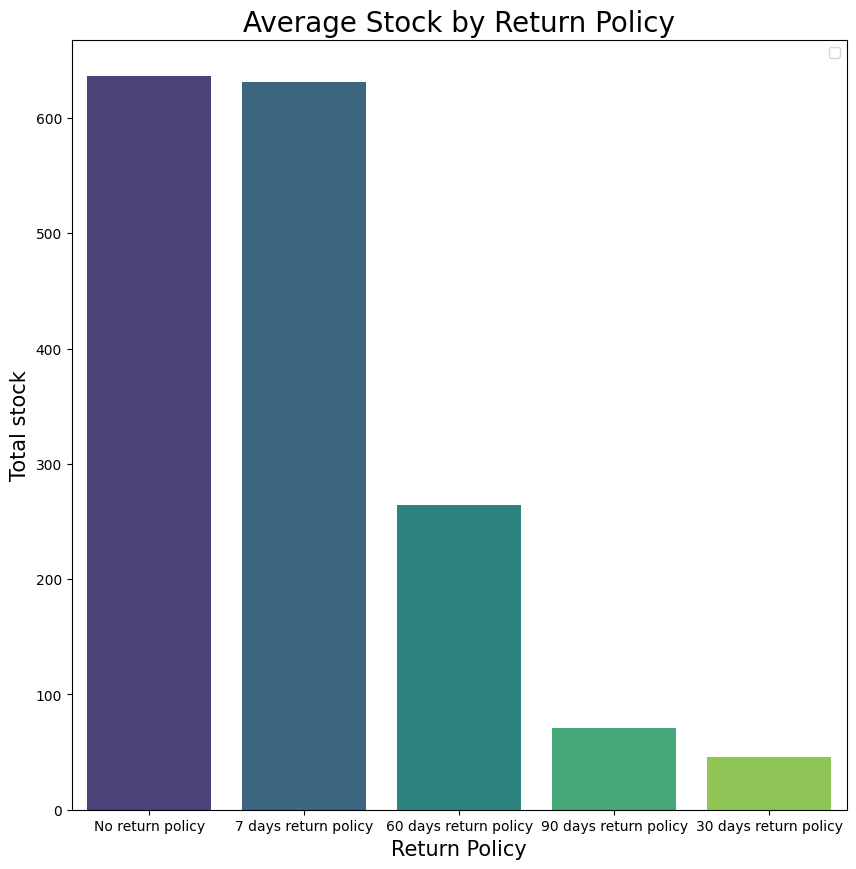

In [160]:
products_graph=create_bar_chart(
    dataframe=products_df,
    x_column="returnPolicy",
    y_column="stock",
    estimator="sum",
    chart_title="Average Stock by Return Policy",
    x_title="Return Policy",
    y_title="Total stock"
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_6960\2104945075.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart= sns.barplot(
C:\Users\Dell\AppData\Local\Temp\ipykernel_6960\2104945075.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


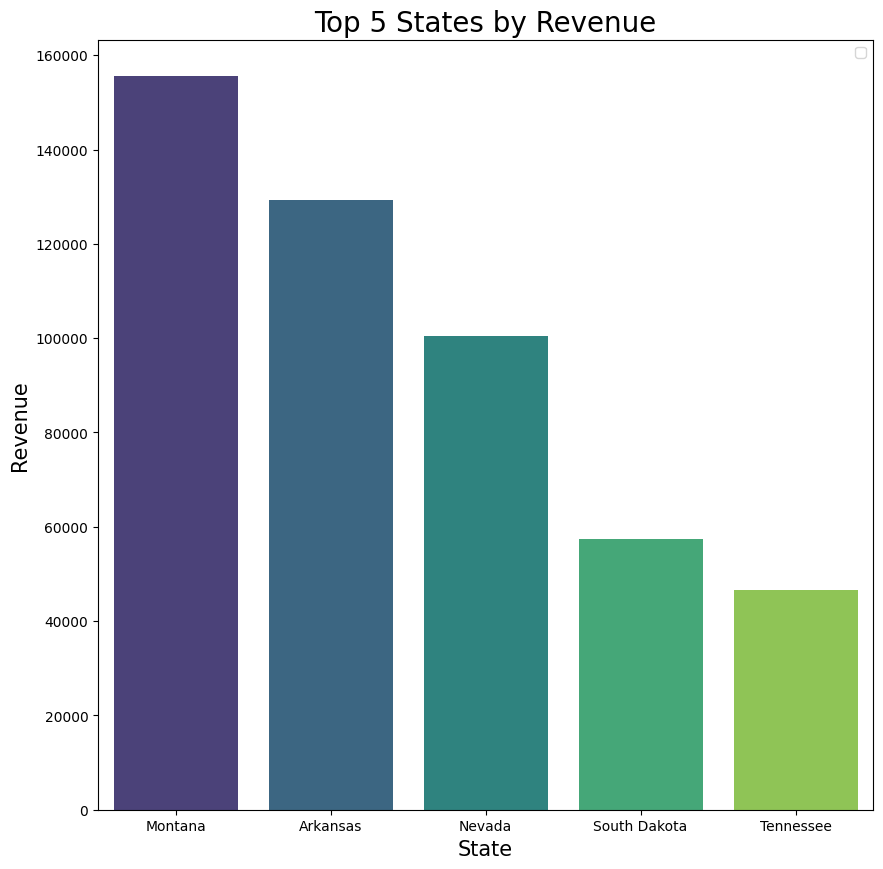

In [161]:
state_graph=create_bar_chart(group_state.head(5),
                             "address.stateCode",
                             "discountedTotal","sum",
                             "Top 5 States by Revenue",
                             "State",
                             "Revenue",
                             )

C:\Users\Dell\AppData\Local\Temp\ipykernel_6960\2217459547.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatterplot=sns.scatterplot(


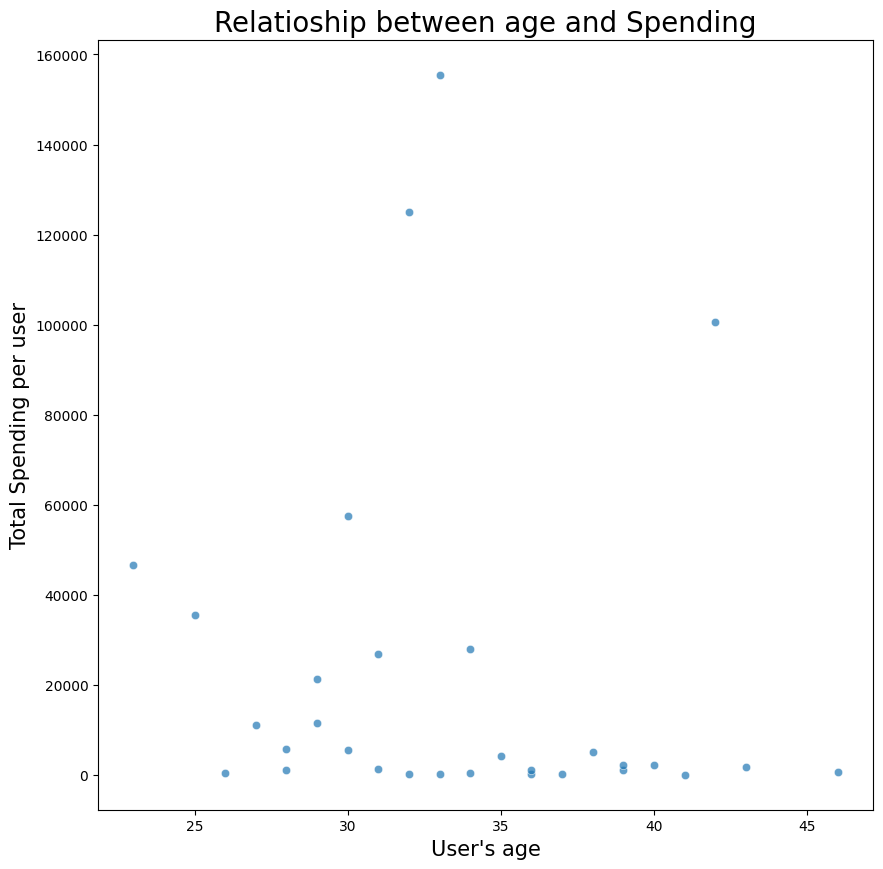

In [162]:
age_revenue_graph=create_scatterplot(
    group_user,
    "age",
    "discountedTotal",
    "Relatioship between age and Spending",
    "User's age",
    "Total Spending per user"
)

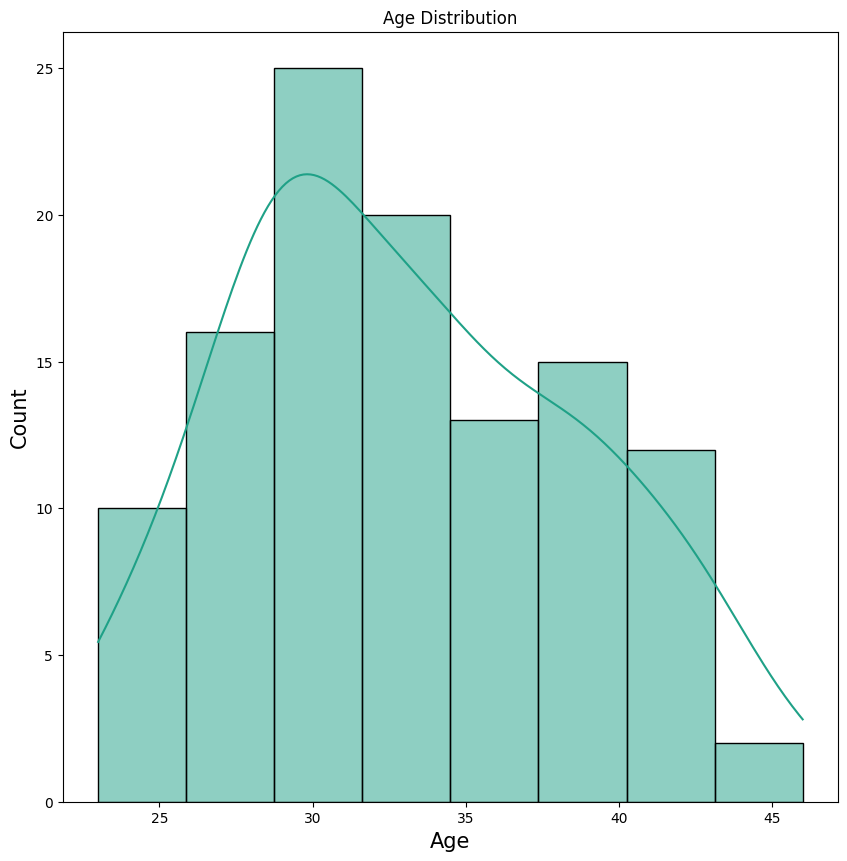

In [190]:
histogram=create_histogram(orders_merged,"age")

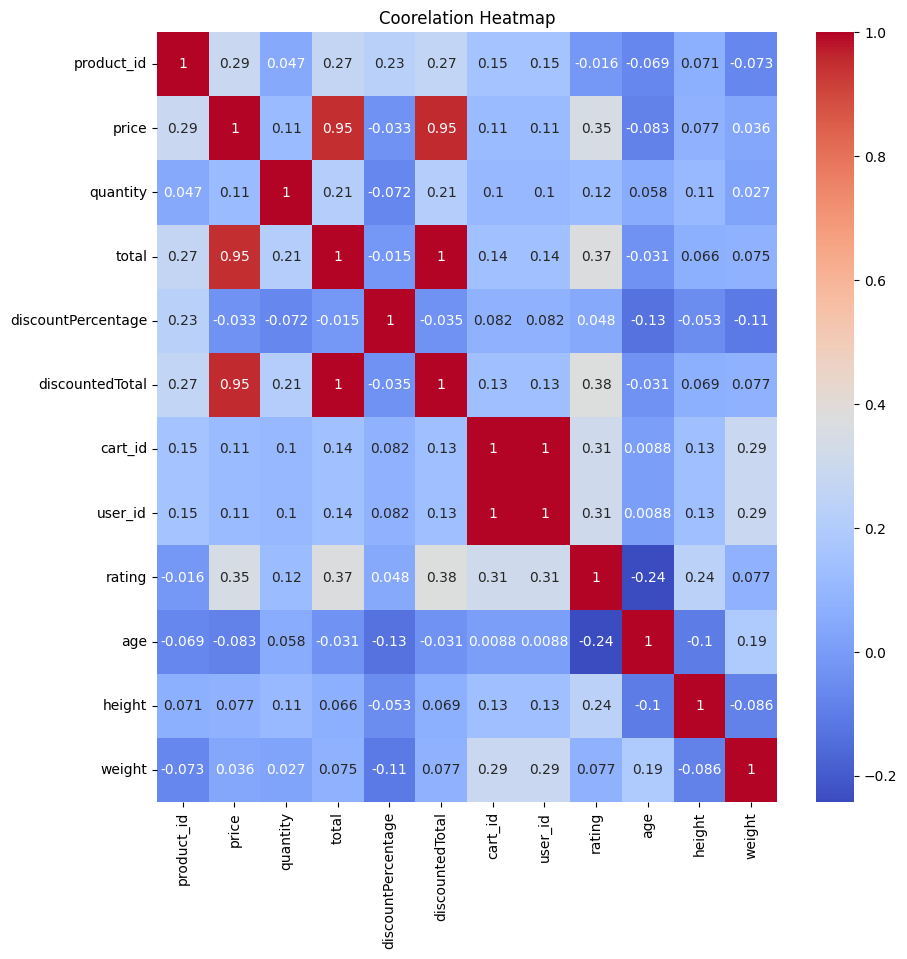

In [194]:
heatmap=create_heatmap(
    orders_merged,
    orders_merged.select_dtypes(include="number").columns
    )